In [1]:
import yfinance as yf
import pandas as pd
import datetime as d
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
import warnings
warnings.filterwarnings(action='ignore')

In [2]:
s=d.datetime(2025,1,1)
e=d.datetime(2026,4,4)

In [3]:
tcs=yf.download('TCS.ns', start=s, end=e)
tcs.columns=tcs.columns.get_level_values(0)
tcs['Stock'] = 'TCS' 

[*********************100%***********************]  1 of 1 completed


In [4]:
wipro=yf.download('Wipro.ns', start=s, end=e)
wipro.columns=wipro.columns.get_level_values(0)
wipro['Stock']='Wipro'

[*********************100%***********************]  1 of 1 completed


In [5]:
infosys=yf.download('INFY.ns', start=s, end=e)
infosys.columns=infosys.columns.get_level_values(0)
infosys['Stock']='INFY'

[*********************100%***********************]  1 of 1 completed


In [6]:
hcltech=yf.download('HCLTECH.ns', start=s, end=e)
hcltech.columns=hcltech.columns.get_level_values(0)
hcltech['Stock']='HCLTECH'

[*********************100%***********************]  1 of 1 completed


In [7]:
techmahindra =yf.download('TECHM.ns', start=s, end=e)
techmahindra.columns=techmahindra.columns.get_level_values(0)
techmahindra['Stock']='TECHM'

[*********************100%***********************]  1 of 1 completed


In [8]:
ltimindtree =yf.download('LTIM.ns', start=s, end=e)
ltimindtree.columns=ltimindtree.columns.get_level_values(0)
ltimindtree['Stock']='LTIM'

[*********************100%***********************]  1 of 1 completed


In [9]:
persistent =yf.download('PERSISTENT.ns', start=s, end=e)
persistent.columns=persistent.columns.get_level_values(0)
persistent['Stock']='PERSISTENT'

[*********************100%***********************]  1 of 1 completed


In [10]:
oracle =yf.download('OFSS.ns', start=s, end=e)
oracle.columns=oracle.columns.get_level_values(0)
oracle['Stock']='OFSS'

[*********************100%***********************]  1 of 1 completed


In [11]:
coforge =yf.download('COFORGE.ns', start=s, end=e)
coforge.columns=coforge.columns.get_level_values(0)
coforge['Stock']='COFORGE'

[*********************100%***********************]  1 of 1 completed


In [12]:
mphasis =yf.download('MPHASIS.ns', start=s, end=e)
mphasis.columns=mphasis.columns.get_level_values(0)
mphasis['Stock']='MPHASIS'

[*********************100%***********************]  1 of 1 completed


In [13]:
df=pd.concat([tcs, wipro, infosys, hcltech, techmahindra, ltimindtree, persistent, oracle, coforge, mphasis], axis=0)

In [14]:
df

Price,Close,High,Low,Open,Volume,Stock
Date,,,,,,
2025-01-01,3903.252930,3923.706512,3877.626168,3886.120842,763161,TCS
2025-01-02,3963.332764,3970.213962,3888.541445,3910.418724,1720835,TCS
2025-01-03,3891.341064,3967.319259,3884.127810,3967.319259,1791953,TCS
2025-01-06,3886.690430,3938.560333,3859.545197,3896.656303,2085593,TCS
2025-01-07,3823.383057,3929.733193,3807.485118,3905.625367,2669054,TCS
...,...,...,...,...,...,...
2026-03-25,2132.100098,2154.399902,2100.899902,2139.899902,1105605,MPHASIS
2026-03-27,2117.000000,2147.899902,2097.100098,2115.000000,648475,MPHASIS
2026-03-30,2053.000000,2099.899902,2013.000000,2080.000000,768221,MPHASIS


In [17]:
t=df[df.Stock == 'TCS']
w=df[df.Stock =='Wipro']
i=df[df.Stock=='INFY']
h=df[df.Stock=='HCLTECH']
m=df[df.Stock=='TECHM']
l=df[df.Stock=='LTIM']
p=df[df.Stock=='PERSISTENT']
o=df[df.Stock=='OFSS']
c=df[df.Stock=='COFORGE']
mp=df[df.Stock=='MPHASIS']

In [18]:
t=t[['Close']]
t['Returns']=t['Close'].pct_change()
t.dropna(inplace=True)

In [35]:
#step 3: stationarity check using Augmented Dickey-Fuller (ADF) test
def check_stationarity(timeseries):
    result= adfuller(timeseries.dropna())
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    
    if result[1]<0.05:
        print("The series is stationary.")
    else:
        print("The series is NOT stationary")

check_stationarity(t['Close'])

ADF Statistic: -1.1197066933515907
p-value: 0.7071494668978778
The series is NOT stationary


In [37]:
t['Close_Diff']=t['Close'].diff().dropna()
check_stationarity(t['Close_Diff'])

ADF Statistic: -18.23243959832728
p-value: 2.3654895002500038e-30
The series is stationary.


In [39]:
model=ARIMA(t['Close'], order=(5,1,0)) # AR(5), I(1), MA(0)
model_fit= model.fit()

In [40]:
forecasting = model_fit.forecast(steps=10)
dates=pd.date_range(start=t.index[-1], periods=11, freq='B')[1:]

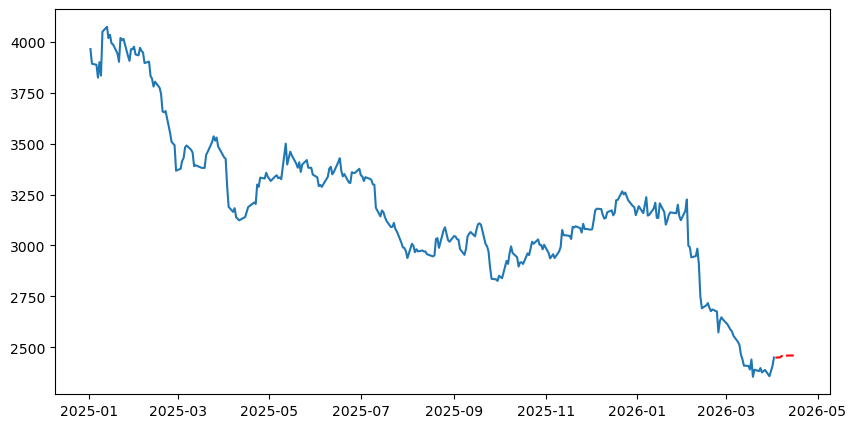

In [41]:
plt.figure(figsize=(10,5))
plt.plot(t['Close'], label="Actual Prices")
plt.plot(dates, forecasting, label="Predicted Prices", linestyle="dashed", color="red")
plt.show()

In [42]:
check_stationarity(w['Close'])

ADF Statistic: -1.0145061234108599
p-value: 0.7479368256933815
The series is NOT stationary


In [46]:
w['Close_Diff']=w['Close'].diff().dropna()
check_stationarity(w['Close_Diff'])

ADF Statistic: -19.730204899033176
p-value: 0.0
The series is stationary.


In [47]:
model=ARIMA(w['Close'], order=(5,1,0)) # AR(5), I(1), MA(0)
model_fit= model.fit()

In [48]:
forecasting = model_fit.forecast(steps=10)
dates=pd.date_range(start=w.index[-1], periods=11, freq='B')[1:]

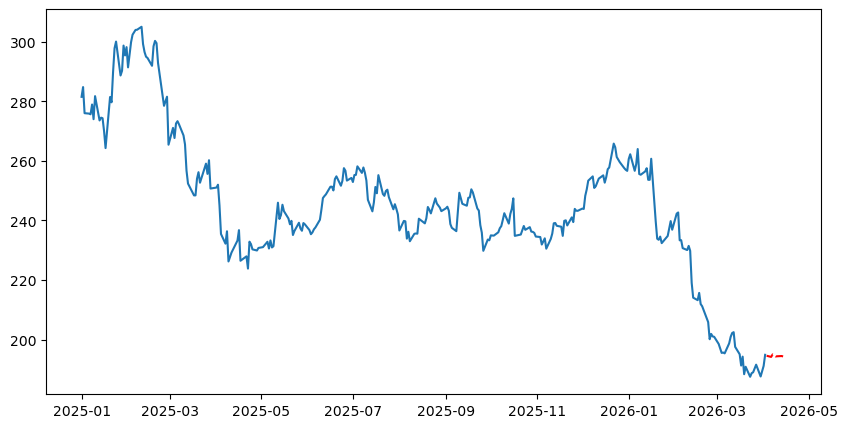

In [49]:
plt.figure(figsize=(10,5))
plt.plot(w['Close'], label="Actual Prices")
plt.plot(dates, forecasting, label="Predicted Prices", linestyle="dashed", color="red")
plt.show()

In [50]:
check_stationarity(i['Close'])

ADF Statistic: -1.689505947473411
p-value: 0.43652727767892063
The series is NOT stationary


In [52]:
i['Close_Diff']=i['Close'].diff().dropna()
check_stationarity(i['Close_Diff'])

ADF Statistic: -19.07113420296616
p-value: 0.0
The series is stationary.


In [58]:
model=ARIMA(i['Close'], order=(5,1,0)) # AR(5), I(1), MA(0)
model_fit= model.fit()

In [60]:
forecasting = model_fit.forecast(steps=10)
dates=pd.date_range(start=i.index[-1], periods=11, freq='B')[1:]

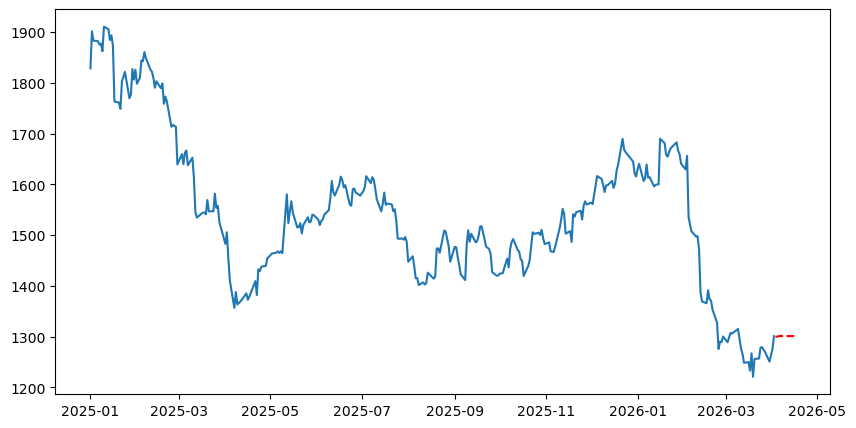

In [63]:
plt.figure(figsize=(10,5))
plt.plot(i['Close'], label="Actual Prices")
plt.plot(dates, forecasting, label="Predicted Prices", linestyle="dashed", color="red")
plt.show()

In [64]:
check_stationarity(h['Close'])

ADF Statistic: -2.3278586535013734
p-value: 0.16314033805587208
The series is NOT stationary


In [65]:
h['Close_Diff']=h['Close'].diff().dropna()
check_stationarity(h['Close_Diff'])

ADF Statistic: -18.195371794373585
p-value: 2.4134026309638555e-30
The series is stationary.


In [66]:
model=ARIMA(h['Close'], order=(5,1,0)) # AR(5), I(1), MA(0)
model_fit= model.fit()

In [67]:
forecasting = model_fit.forecast(steps=10)
dates=pd.date_range(start=h.index[-1], periods=11, freq='B')[1:]

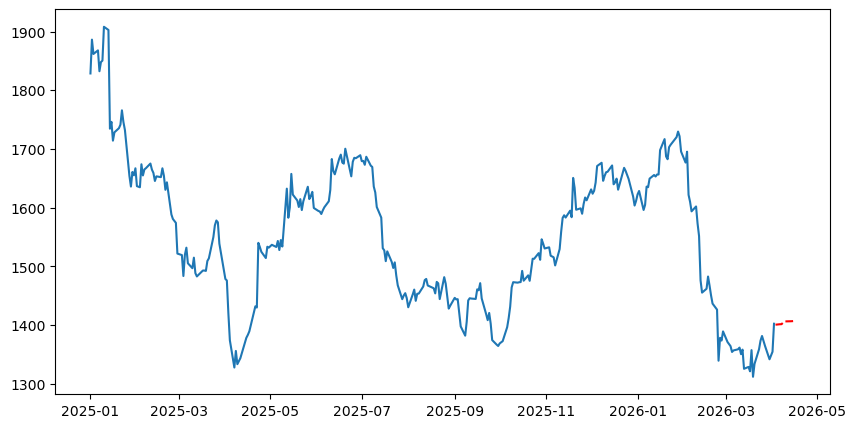

In [73]:
plt.figure(figsize=(10,5))
plt.plot(h['Close'], label="Actual Prices")
plt.plot(dates, forecasting, label="Predicted Prices", linestyle="dashed", color="red")
plt.show()

In [74]:
check_stationarity(m['Close'])

ADF Statistic: -2.857653066335284
p-value: 0.050498631340130766
The series is NOT stationary


In [77]:
m['Close_Diff']=m['Close'].diff().dropna()
check_stationarity(m['Close_Diff'])

ADF Statistic: -7.259490798105023
p-value: 1.6962010115923051e-10
The series is stationary.


In [78]:
model=ARIMA(m['Close'], order=(5,1,0)) # AR(5), I(1), MA(0)
model_fit= model.fit()

In [81]:
forecasting = model_fit.forecast(steps=10)
dates=pd.date_range(start=m.index[-1], periods=11, freq='B')[1:]

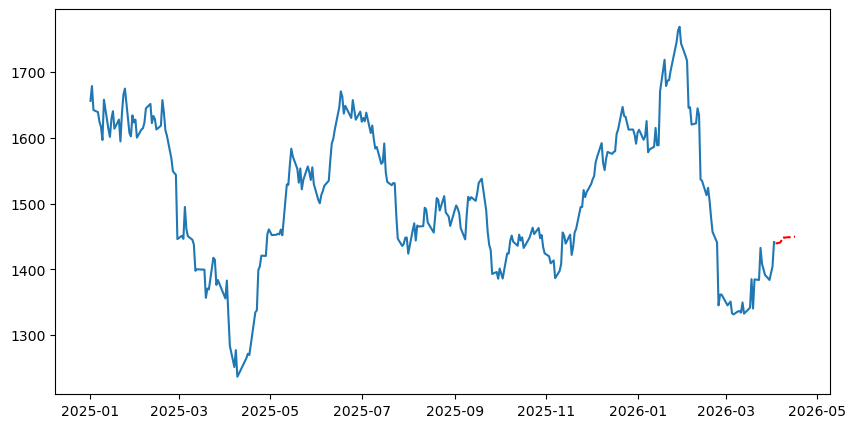

In [83]:
plt.figure(figsize=(10,5))
plt.plot(m['Close'], label="Actual Prices")
plt.plot(dates, forecasting, label="Predicted Prices", linestyle="dashed", color="red")
plt.show()

In [84]:
check_stationarity(l['Close'])

ADF Statistic: -1.5480820384598397
p-value: 0.5096061006469796
The series is NOT stationary


In [87]:
l['Close_Diff']=l['Close'].diff().dropna()
check_stationarity(l['Close_Diff'])

ADF Statistic: -5.537756135862387
p-value: 1.7292060878897127e-06
The series is stationary.


In [89]:
model=ARIMA(l['Close'], order=(5,1,0)) # AR(5), I(1), MA(0)
model_fit= model.fit()

In [91]:
forecasting = model_fit.forecast(steps=10)
dates=pd.date_range(start=l.index[-1], periods=11, freq='B')[1:]

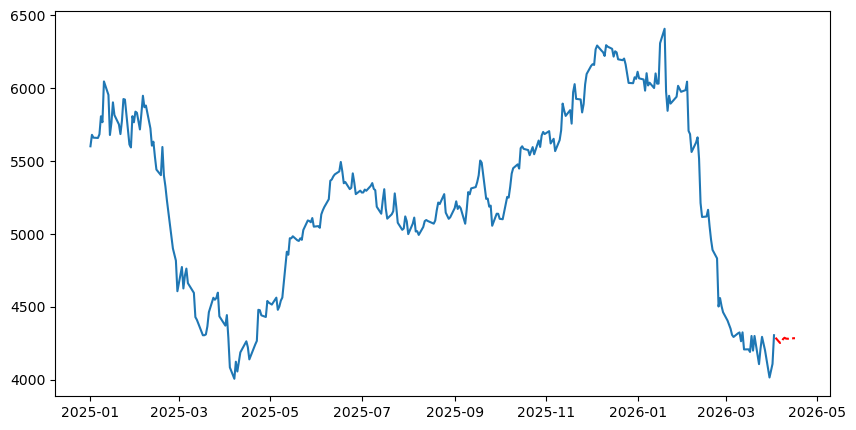

In [93]:
plt.figure(figsize=(10,5))
plt.plot(l['Close'], label="Actual Prices")
plt.plot(dates, forecasting, label="Predicted Prices", linestyle="dashed", color="red")
plt.show()

In [94]:
check_stationarity(p['Close'])

ADF Statistic: -2.33815514864244
p-value: 0.15995721463431423
The series is NOT stationary


In [95]:
p['Close_Diff']=p['Close'].diff().dropna()
check_stationarity(p['Close_Diff'])

ADF Statistic: -17.385575498293495
p-value: 5.0437531452699316e-30
The series is stationary.


In [97]:
model=ARIMA(p['Close'], order=(5,1,0)) # AR(5), I(1), MA(0)
model_fit= model.fit()

In [100]:
forecasting = model_fit.forecast(steps=10)
dates=pd.date_range(start=p.index[-1], periods=11, freq='B')[1:]

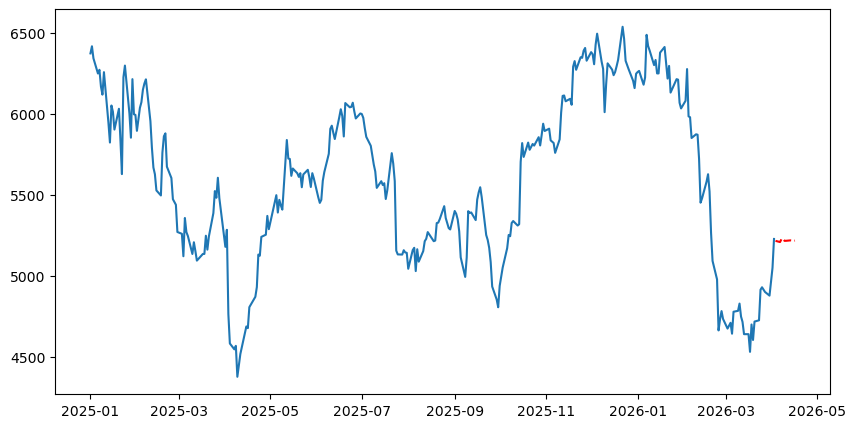

In [101]:
plt.figure(figsize=(10,5))
plt.plot(p['Close'], label="Actual Prices")
plt.plot(dates, forecasting, label="Predicted Prices", linestyle="dashed", color="red")
plt.show()

In [102]:
check_stationarity(o['Close'])

ADF Statistic: -3.772513021837267
p-value: 0.0032014003613759917
The series is stationary.


In [107]:
model=ARIMA(o['Close'], order=(5,1,0)) # AR(5), I(1), MA(0)
model_fit= model.fit()

In [108]:
forecasting = model_fit.forecast(steps=10)
dates=pd.date_range(start=o.index[-1], periods=11, freq='B')[1:]

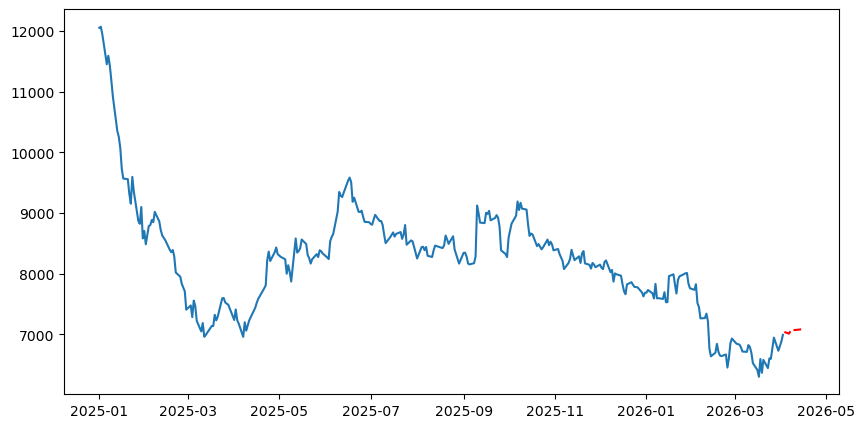

In [109]:
plt.figure(figsize=(10,5))
plt.plot(o['Close'], label="Actual Prices")
plt.plot(dates, forecasting, label="Predicted Prices", linestyle="dashed", color="red")
plt.show()

In [110]:
check_stationarity(c['Close'])

ADF Statistic: -1.2255641624502516
p-value: 0.6625031279255357
The series is NOT stationary


In [113]:
c['Close_Diff']=c['Close'].diff().dropna()
check_stationarity(c['Close_Diff'])

ADF Statistic: -16.508968434793992
p-value: 2.1145738999473115e-29
The series is stationary.


In [114]:
model=ARIMA(c['Close'], order=(5,1,0)) # AR(5), I(1), MA(0)
model_fit= model.fit()

In [115]:
forecasting = model_fit.forecast(steps=10)
dates=pd.date_range(start=c.index[-1], periods=11, freq='B')[1:]

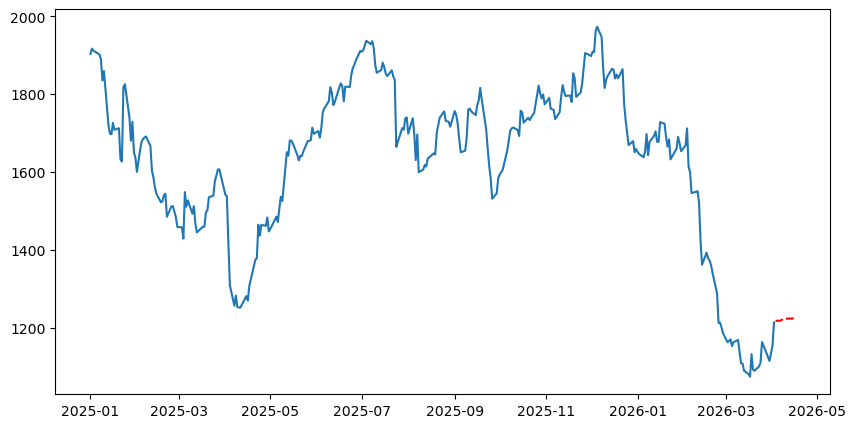

In [116]:
plt.figure(figsize=(10,5))
plt.plot(c['Close'], label="Actual Prices")
plt.plot(dates, forecasting, label="Predicted Prices", linestyle="dashed", color="red")
plt.show()

In [122]:
check_stationarity(mp['Close'])

ADF Statistic: -1.4412428313087506
p-value: 0.5623519863679868
The series is NOT stationary


In [123]:
mp['Close_Diff']=mp['Close'].diff().dropna()
check_stationarity(mp['Close_Diff'])

ADF Statistic: -16.63321509892881
p-value: 1.6590235038264635e-29
The series is stationary.


In [124]:
model=ARIMA(mp['Close'], order=(5,1,0)) # AR(5), I(1), MA(0)
model_fit= model.fit()

In [125]:
forecasting = model_fit.forecast(steps=10)
dates=pd.date_range(start=mp.index[-1], periods=11, freq='B')[1:]

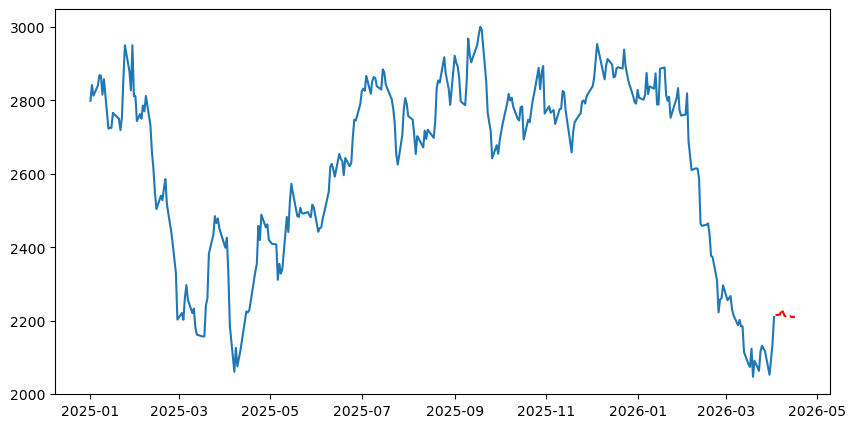

In [126]:
plt.figure(figsize=(10,5))
plt.plot(mp['Close'], label="Actual Prices")
plt.plot(dates, forecasting, label="Predicted Prices", linestyle="dashed", color="red")
plt.show()

In [ ]:
print(df.Stock.unique())
s=input("Enter Stock Name: ")
s=df[df.Stock==s]

plt.figure(figsize=(10,5))
plt.plot(t['Close'], label="Actual Prices")
plt.plot(dates, forecasting, label="Predicted Prices", linestyle="dashed", color="red")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(w['Close'], label="Actual Prices")
plt.plot(dates, forecasting, label="Predicted Prices", linestyle="dashed", color="red")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(i['Close'], label="Actual Prices")
plt.plot(dates, forecasting, label="Predicted Prices", linestyle="dashed", color="red")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(h['Close'], label="Actual Prices")
plt.plot(dates, forecasting, label="Predicted Prices", linestyle="dashed", color="red")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(m['Close'], label="Actual Prices")
plt.plot(dates, forecasting, label="Predicted Prices", linestyle="dashed", color="red")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(l['Close'], label="Actual Prices")
plt.plot(dates, forecasting, label="Predicted Prices", linestyle="dashed", color="red")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(p['Close'], label="Actual Prices")
plt.plot(dates, forecasting, label="Predicted Prices", linestyle="dashed", color="red")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(o['Close'], label="Actual Prices")
plt.plot(dates, forecasting, label="Predicted Prices", linestyle="dashed", color="red")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(c['Close'], label="Actual Prices")
plt.plot(dates, forecasting, label="Predicted Prices", linestyle="dashed", color="red")
plt.show()

plt.figure(figsize=(10,5))
plt.plot(mp['Close'], label="Actual Prices")
plt.plot(dates, forecasting, label="Predicted Prices", linestyle="dashed", color="red")
plt.show()

['TCS' 'Wipro' 'INFY' 'HCLTECH' 'TECHM' 'LTIM' 'PERSISTENT' 'OFSS'
 'COFORGE' 'MPHASIS']
